# This notebook will primarly be used for MoE and Distance from perfect forecast calculation from the West-WRF model 
- This Notebook was authored by: Sina Shamsian 
- Date: 07/16/26
- Natural flow of this notebook will be: 
1. Importing python packages 
2. defining important functions 
3. MoE calculations 
4. Distance from perfect forecast calculations 
5. plots of both MoE and distance from perfect forecast 

## Importing packages 

In [2]:
import pandas as pd 
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
import re
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Defining important functions 

In [22]:
def compute_moe(df):
    """Compute the Measure of Effectiveness (MoE) per DeHaan et al. 2021 (WAF).

    x_moe = intersect_area / obs_area   (false-negative measure)
    y_moe = intersect_area / fcst_area  (false-positive measure)

    Points on the y=x diagonal indicate forecast and observed objects
    are the same size (not necessarily same location).
    Above the diagonal: forecast object smaller than observed.
    Below the diagonal: forecast object larger than observed.
    """
    df = df.copy()
    df['x_moe'] = df['intersect_area'] / df['obs_area']
    df['y_moe'] = df['intersect_area'] / df['fcst_area']
    return df
def dist_perf(x_moe, y_moe, normalize=True):
    """Compute the distance from the perfect forecast point (1,1) in MoE space.

    Parameters
    ----------
    x_moe, y_moe : float or array-like
        MoE coordinates (intersect/obs and intersect/fcst ratios), each in [0, 1].
    normalize : bool
        If True, divide by sqrt(2) (max possible distance) so output is in [0, 1],
        where 0 = perfect forecast and 1 = complete miss.

    Returns
    -------
    float or array-like
        Distance from perfect forecast, in [0, sqrt(2)] or [0, 1] if normalized.
    """
    dist = np.sqrt((x_moe - 1)**2 + (y_moe - 1)**2)
    if normalize:
        dist = dist / np.sqrt(2)
    return dist
def clean_secondary_csv(path):
    """Read and clean a single MODE secondary-output CSV (all leads in one file)."""
    df = pd.read_csv(path, sep='\s+', engine='python', header=0)

    # Parse valid_time into a real datetime
    df['valid_time'] = pd.to_datetime(df['valid_time'], format='%Y%m%d_%H%M%S')

    # Convert lead_time from MET's HHMMSS-style int into plain hours
    df['lead_hours'] = (df['lead_time'] // 10000).astype(int)
    df = df.drop(columns=['lead_time'])

    # Round numeric columns for readability
    numeric_cols = ['centroid_lat', 'centroid_lon', 'intersect_area',
                     'fcst_90', 'obs_90', 'fcst_area', 'obs_area',
                     'fcst_angle', 'obs_angle']
    df[numeric_cols] = df[numeric_cols].round(2)

    # Reorder and sort
    cols_order = ['valid_time', 'lead_hours', 'centroid_lat', 'centroid_lon',
                  'intersect_area', 'fcst_90', 'obs_90', 'fcst_area', 'obs_area',
                  'fcst_angle', 'obs_angle']
    df = df[cols_order]
    df = df.sort_values('lead_hours').reset_index(drop=True)
    df = df.sort_values('obs_area', ascending=False).drop_duplicates(subset='lead_hours', keep='first')
    df['source_file'] = path
    return df

def load_secondary_for_date_1990s(init_str, ivt_level=500,
                              base_path='/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Secondary_output/1***'):
    """Load and clean the secondary-output CSV for one init-time directory."""
    pattern = f'{base_path}/{init_str}/{ivt_level}/MODE_WestWRF_500*.csv'
    files = sorted(glob.glob(pattern))
    if not files:
        print(f'No secondary CSV found for {init_str} at {pattern}')
        return pd.DataFrame()

    if len(files) > 1:
        print(f'WARNING: expected 1 CSV for {init_str}, found {len(files)}: {files}')

    return clean_secondary_csv(files[0])

def load_secondary_for_dates_1990s(dates, ivt_level=500,
                               base_path='/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Secondary_output/1***'):
    """Load and concatenate secondary-output CSVs across multiple init-time directories.

    Parameters
    ----------
    dates : list of (init_str, label) tuples
        e.g. [('1998013100', 'Jan 31, 1998 00Z'), ('1998020100', 'Feb 1, 1998 00Z'), ...]

    Returns
    -------
    dict
        Keyed by label, each value the cleaned DataFrame for that date.
    """
    result = {}
    for init_str, label in dates:
        df = load_secondary_for_date_1990s(init_str, ivt_level=ivt_level, base_path=base_path)
        if df.empty:
            print(f'No data for {label} - skipping')
            continue
        df['date_label'] = label
        result[label] = df
    return result

<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_30845/1747354219.py:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(path, sep='\s+', engine='python', header=0)


### winter of 1998-1999 important dates 

In [23]:
start_date = '1998-12-08'
end_date = '1999-03-31'

date_range = pd.date_range(start=start_date, end=end_date, freq='D')

dates = [
    (d.strftime('%Y%m%d') + '00', d.strftime('%b %-d, %Y 00Z'))
    for d in date_range
]

print(f'Generated {len(dates)} dates')
print(dates[:5])   # first few
print(dates[-5:])  # last few

Generated 114 dates
[('1998120800', 'Dec 8, 1998 00Z'), ('1998120900', 'Dec 9, 1998 00Z'), ('1998121000', 'Dec 10, 1998 00Z'), ('1998121100', 'Dec 11, 1998 00Z'), ('1998121200', 'Dec 12, 1998 00Z')]
[('1999032700', 'Mar 27, 1999 00Z'), ('1999032800', 'Mar 28, 1999 00Z'), ('1999032900', 'Mar 29, 1999 00Z'), ('1999033000', 'Mar 30, 1999 00Z'), ('1999033100', 'Mar 31, 1999 00Z')]


### Calculating distance from perfect forecast to plot into a 2D histogram

Loaded 87 dates out of 114 requested
Total rows: 537
lead_hours
24     86
48     80
72     79
96     73
120    76
144    74
168    69
dtype: int64
Requested: 114, Found: 87, Missing: 27

Dec 20, 1998 00Z (1998122000)
Dec 21, 1998 00Z (1998122100)
Dec 22, 1998 00Z (1998122200)
Jan 2, 1999 00Z (1999010200)
Jan 5, 1999 00Z (1999010500)
Jan 6, 1999 00Z (1999010600)
Jan 25, 1999 00Z (1999012500)
Jan 26, 1999 00Z (1999012600)
Jan 30, 1999 00Z (1999013000)
Jan 31, 1999 00Z (1999013100)
Feb 19, 1999 00Z (1999021900)
Feb 20, 1999 00Z (1999022000)
Mar 1, 1999 00Z (1999030100)
Mar 4, 1999 00Z (1999030400)
Mar 5, 1999 00Z (1999030500)
Mar 8, 1999 00Z (1999030800)
Mar 9, 1999 00Z (1999030900)
Mar 10, 1999 00Z (1999031000)
Mar 15, 1999 00Z (1999031500)
Mar 16, 1999 00Z (1999031600)
Mar 17, 1999 00Z (1999031700)
Mar 20, 1999 00Z (1999032000)
Mar 21, 1999 00Z (1999032100)
Mar 26, 1999 00Z (1999032600)
Mar 27, 1999 00Z (1999032700)
Mar 29, 1999 00Z (1999032900)
Mar 30, 1999 00Z (1999033000)


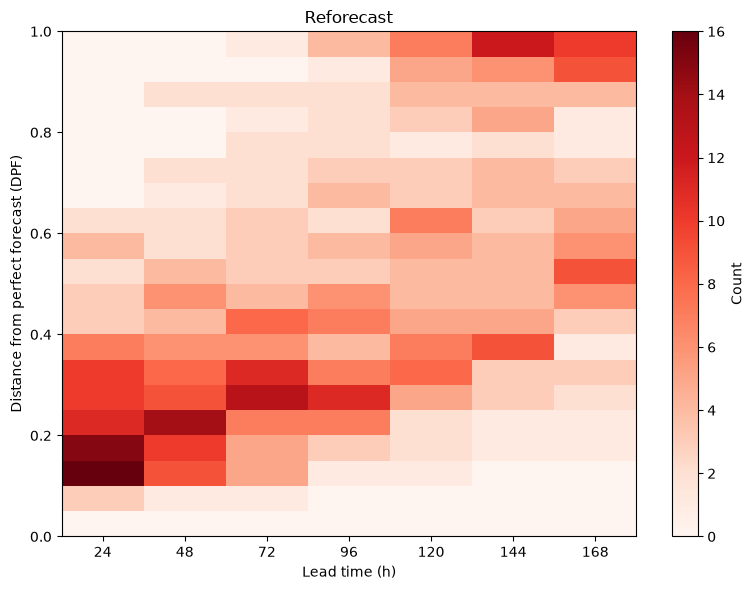

In [24]:
# --- load every date in the season, compute MoE + DPF, and stack into ONE long dataframe ---
ivt_level = 500
all_rows = []

for init_str, label in dates:
    df = load_secondary_for_date_1990s(init_str, ivt_level=ivt_level)
    if df.empty:
        continue
    df = compute_moe(df)
    df['dist_perf'] = dist_perf(df['x_moe'], df['y_moe'])
    df['init_str'] = init_str
    all_rows.append(df)

season_df = pd.concat(all_rows, ignore_index=True)
season_df 
print(f'Loaded {season_df["init_str"].nunique()} dates out of {len(dates)} requested')
print(f'Total rows: {len(season_df)}')
print(season_df.groupby('lead_hours').size())  # how many samples per lead
#----Diganostic to check missing dates----------------------#
found_init_strs = set(season_df['init_str'].unique())

missing_dates = []
for init_str, label in dates:
    if init_str not in found_init_strs:
        missing_dates.append((init_str, label))
#-----------------------------------------------------------#

print(f'Requested: {len(dates)}, Found: {len(found_init_strs)}, Missing: {len(missing_dates)}')
print()
for init_str, label in missing_dates:
    print(f'{label} ({init_str})')

# -----------------------------------------------------------------------------
# 2-D histograms (heat maps) of MoE, one per lead time, bin size 0.05
# -----------------------------------------------------------------------------
lead_hours = [24, 48, 72, 96, 120, 144, 168]
dpf_bins = np.arange(0, 1.05, 0.05)  # 0 to 1 in steps of 0.05
dpf_bin_centers = (dpf_bins[:-1] + dpf_bins[1:]) / 2

# --- build a 2D array: rows = DPF bins, columns = lead times, values = counts ---
heatmap_data = np.zeros((len(dpf_bin_centers), len(lead_hours)))

for j, lead in enumerate(lead_hours):
    subset = season_df[season_df['lead_hours'] == lead]
    counts, _ = np.histogram(subset['dist_perf'], bins=dpf_bins)
    heatmap_data[:, j] = counts

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(np.arange(len(lead_hours) + 1), dpf_bins, heatmap_data,
                     cmap='Reds', shading='flat')

ax.set_xticks(np.arange(len(lead_hours)) + 0.5)
ax.set_xticklabels(lead_hours)
ax.set_xlabel('Lead time (h)')
ax.set_ylabel('Distance from perfect forecast (DPF)')
ax.set_title('Reforecast')

cbar = fig.colorbar(im, ax=ax, label='Count')

plt.tight_layout()
plt.show()
